#                                  timeseris Multi Class Clasification - RNN

# Load Data

In [56]:
import pandas as pd
import os
import numpy as np

In [57]:

file_name = "microsoft_stock_data"
root_folder = f'timeseris/multi-class-clasification/rnn/{file_name}/' 
os.makedirs(root_folder, exist_ok=True)

df = pd.read_csv('sample_data/'+file_name+'.csv')

df.head()

,Date,Close,High,Low,Open,Volume
0,3/26/1986,0.057906,0.058437,0.055781,0.056312,22752000
1,3/27/1986,0.058969,0.058969,0.057906,0.057906,16848000
2,3/31/1986,0.058437,0.058969,0.057375,0.058969,12873600
3,4/1/1986,0.057906,0.058437,0.057906,0.058437,11088000
4,4/2/1986,0.058437,0.059500,0.057906,0.057906,27014400


#### Pilih tahun mulai data

In [58]:
# Pastikan kolom Date dalam format datetime
df['Date'] = pd.to_datetime(df['Date'])

# Filter data mulai dari tahun 2000
df = df[df['Date'] >= '1999-01-01']

# (Opsional) urutkan berdasarkan tanggal
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Close,High,Low,Open,Volume
0,1999-01-04,21.572977,22.223226,21.324352,21.360212,69305200
1,1999-01-05,22.414471,22.643970,21.639909,21.706847,64281600
2,1999-01-06,23.141226,23.179476,22.452727,22.873476,69064800
3,1999-01-07,23.026478,23.045603,22.682228,22.911728,51150400
4,1999-01-08,22.930851,23.332476,22.490976,23.284663,50244800


#### tambahkan status green, red, dan netral || DayName

In [59]:
# === Tambahkan kolom nama hari ===
df['Day'] =  df['Date'].dt.day_name()  # bahasa Inggris

# Buat kondisi
conditions = [
    df['Close'] > df['Open'],
    df['Close'] < df['Open'],
    df['Close'] == df['Open']
]
choices = ['green', 'red', 'red']

df['Status'] = np.select(conditions, choices)
df.head()

,Date,Close,High,Low,Open,Volume,Day,Status
0,1999-01-04,21.572977,22.223226,21.324352,21.360212,69305200,Monday,green
1,1999-01-05,22.414471,22.643970,21.639909,21.706847,64281600,Tuesday,green
2,1999-01-06,23.141226,23.179476,22.452727,22.873476,69064800,Wednesday,green
3,1999-01-07,23.026478,23.045603,22.682228,22.911728,51150400,Thursday,green
4,1999-01-08,22.930851,23.332476,22.490976,23.284663,50244800,Friday,red


#### Chart Donat

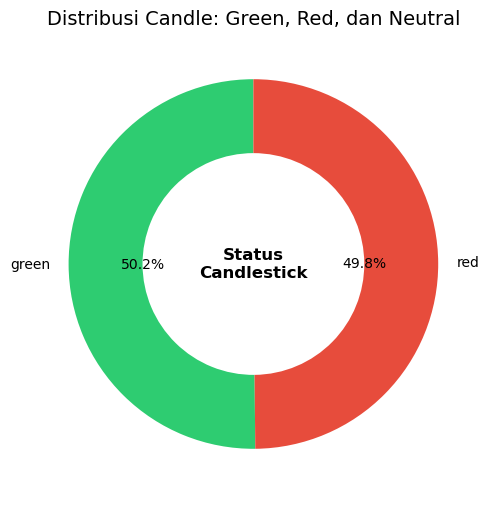

In [60]:
import matplotlib.pyplot as plt

# Contoh: df sudah punya kolom Status
# (kalau belum, bisa pakai kode sebelumnya untuk menambahkannya)

# Hitung jumlah masing-masing status
status_counts = df['Status'].value_counts()

# Warna donat
colors = {
    'green': '#2ecc71',   # hijau
    'red': '#e74c3c',     # merah
    'neutral': '#95a5a6'  # abu-abu
}

# Buat donut chart
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[colors[k] for k in status_counts.index],
    wedgeprops=dict(width=0.4)  # buat efek donut
)

# Tambahkan teks di tengah
ax.text(0, 0, 'Status\nCandlestick', ha='center', va='center', fontsize=12, weight='bold')

plt.title('Distribusi Candle: Green, Red, dan Neutral', fontsize=14)
plt.show()

In [61]:
status_counts

Status
green    3381
red      3359
Name: count, dtype: int64

#### LabelEncoder

In [62]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
#labeling
df['label_Day']            = le.fit_transform(df['Day'])


#label target
# Konversi ke kategori otomatis
df["Status"] = df["Status"].astype("category")

# Buat kolom label otomatis (0,1,2,3,...)
df["label_Status"] = df["Status"].cat.codes

labels = dict(enumerate(df["Status"].cat.categories))
print(labels)

{0: 'green', 1: 'red'}


In [63]:
df.head()

,Date,Close,High,Low,Open,Volume,Day,Status,label_Day,label_Status
0,1999-01-04,21.572977,22.223226,21.324352,21.360212,69305200,Monday,green,1,0
1,1999-01-05,22.414471,22.643970,21.639909,21.706847,64281600,Tuesday,green,3,0
2,1999-01-06,23.141226,23.179476,22.452727,22.873476,69064800,Wednesday,green,4,0
3,1999-01-07,23.026478,23.045603,22.682228,22.911728,51150400,Thursday,green,2,0
4,1999-01-08,22.930851,23.332476,22.490976,23.284663,50244800,Friday,red,0,1


#### Scaler

In [64]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Contoh: buat dan fit scaler
scaler = MinMaxScaler()
cols = [
    'label_Day',
    'Close', 
    'High', 
    'Low',
    'Open',
    'Volume', 
]

# Dictionary untuk menyimpan hasil transformasi
scaled_data = {}

# Loop untuk setiap kolom
for col in cols:
    scaler = MinMaxScaler()
    df[[col]] = scaler.fit_transform(df[[col]])  # scaling per kolom
    joblib.dump(scaler, os.path.join(root_folder, f'scaler_{col}.pkl'))
    scaled_data[col] = scaler
    print(f"✅ Scaler for '{col}' saved as scaler_{col}.pkl")

print("\nAll individual scalers saved successfully!")

✅ Scaler for 'label_Day' saved as scaler_label_Day.pkl
✅ Scaler for 'Close' saved as scaler_Close.pkl
✅ Scaler for 'High' saved as scaler_High.pkl
✅ Scaler for 'Low' saved as scaler_Low.pkl
✅ Scaler for 'Open' saved as scaler_Open.pkl
✅ Scaler for 'Volume' saved as scaler_Volume.pkl

All individual scalers saved successfully!


In [65]:
df.head()

,Date,Close,High,Low,Open,Volume,Day,Status,label_Day,label_Status
0,1999-01-04,0.019888,0.019737,0.019942,0.018714,0.106426,Monday,green,0.25,0
1,1999-01-05,0.021495,0.020511,0.020549,0.019352,0.097822,Tuesday,green,0.75,0
2,1999-01-06,0.022883,0.021498,0.022111,0.021500,0.106014,Wednesday,green,1.00,0
3,1999-01-07,0.022664,0.021251,0.022553,0.021571,0.075333,Thursday,green,0.50,0
4,1999-01-08,0.022482,0.021779,0.022185,0.022257,0.073782,Friday,red,0.00,1


#### Mapping label

In [66]:
import json
mapping_dicts = {}

cols = [
    'Day',
]

for col in cols:
    label_col = f"label_{col}"
    mapping_dicts[col] = dict(zip(df[col], df[label_col]))


with open(root_folder + 'label_mappings.json', 'w') as f:
    json.dump(mapping_dicts, f, indent=2)

rows = []
for col, mapping in mapping_dicts.items():
    for k, v in mapping.items():
        rows.append({'feature': col, 'original_value': k, 'label_value': v})

mapping_table = pd.DataFrame(rows)
print(mapping_table)

  feature original_value  label_value
0     Day         Monday         0.25
1     Day        Tuesday         0.75
2     Day      Wednesday         1.00
3     Day       Thursday         0.50
4     Day         Friday         0.00


#### Select Kolom To Trian

In [67]:
col_target = 'label_Status'
cols = [
    'Date',
    'label_Day', 
    'Close', 
    'High',
    'Low',
    'Open',
    'Volume',
    col_target
]
df = df[cols].copy()
df.head()

,Date,label_Day,Close,High,Low,Open,Volume,label_Status
0,1999-01-04,0.25,0.019888,0.019737,0.019942,0.018714,0.106426,0
1,1999-01-05,0.75,0.021495,0.020511,0.020549,0.019352,0.097822,0
2,1999-01-06,1.00,0.022883,0.021498,0.022111,0.021500,0.106014,0
3,1999-01-07,0.50,0.022664,0.021251,0.022553,0.021571,0.075333,0
4,1999-01-08,0.00,0.022482,0.021779,0.022185,0.022257,0.073782,1


# Data Load To Train

#### select Future to traian

In [77]:
feature_cols = [
    'label_Day', 
    'Close', 
    'High',
    'Low',
    'Open',
    'Volume',
    col_target
]
target_cols = col_target

#### Split data

In [78]:
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

tgl_pembatas = '2021-01-01'
X_train = df[df['Date'] <= tgl_pembatas]
X_test  = df[df['Date'] > tgl_pembatas]
print(f'Train : f{X_train.shape}')
print(f'Test  : f{X_test.shape}')

Train : f(5536, 8)
Test  : f(1204, 8)


#### DataLoader

In [79]:
from data_set import MultiClassTimeSeriesDataset
seq_length = 14
slide      = 1
# Buat dataset dengan class kamu
train_dataset = MultiClassTimeSeriesDataset(X_train,seq_length=seq_length, slide=slide, feature_cols=feature_cols, target_cols=target_cols)
test_dataset  = MultiClassTimeSeriesDataset(X_test, seq_length=seq_length, slide=slide, feature_cols=feature_cols, target_cols=target_cols)

# Buat DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Cek contoh batch
for X, y in train_loader:
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print(X[:6])  # contoh fitur
    print(y[:6])  # contoh label
    break

X shape: torch.Size([32, 14, 7])
y shape: torch.Size([32])
tensor([[[0.2500, 0.0199, 0.0197, 0.0199, 0.0187, 0.1064, 0.0000],
         [0.7500, 0.0215, 0.0205, 0.0205, 0.0194, 0.0978, 0.0000],
         [1.0000, 0.0229, 0.0215, 0.0221, 0.0215, 0.1060, 0.0000],
         [0.5000, 0.0227, 0.0213, 0.0226, 0.0216, 0.0753, 0.0000],
         [0.0000, 0.0225, 0.0218, 0.0222, 0.0223, 0.0738, 1.0000],
         [0.2500, 0.0218, 0.0213, 0.0214, 0.0219, 0.0673, 1.0000],
         [0.7500, 0.0202, 0.0205, 0.0204, 0.0211, 0.0869, 1.0000],
         [1.0000, 0.0207, 0.0204, 0.0189, 0.0177, 0.1168, 0.0000],
         [0.5000, 0.0201, 0.0198, 0.0206, 0.0203, 0.0891, 1.0000],
         [0.0000, 0.0224, 0.0211, 0.0205, 0.0197, 0.0894, 0.0000],
         [0.7500, 0.0242, 0.0234, 0.0233, 0.0220, 0.1637, 0.0000],
         [1.0000, 0.0262, 0.0261, 0.0267, 0.0264, 0.2026, 1.0000],
         [0.5000, 0.0249, 0.0248, 0.0253, 0.0250, 0.1249, 1.0000],
         [0.0000, 0.0243, 0.0240, 0.0246, 0.0232, 0.1284, 0.0000]],

 

# Config

In [74]:
from jcopdl.callback import Callback, set_config
config = set_config({
    "labels"         : labels,
    "threshold"      : 0.5,
    "input_size"     : len(test_dataset[0][0][0]),
    "hidden_size"    : 32,
    "num_layers"     : 1,
    "output_size"    : len(labels),
    "dropout"        : 0.1,
    "bidirectional"  : True,
    "early_stop_patience" : 30,
    "col_target"     : col_target,
    "feature_cols"   : feature_cols
})
config

Config(bidirectional=True, col_target=label_Status, dropout=0.1, early_stop_patience=30, feature_cols=['label_Day', 'Close', 'Open', 'Volume'], hidden_size=32, input_size=5, labels={0: 'green', 1: 'red'}, num_layers=1, output_size=2, threshold=0.5)

# MCOC

#### Model - Criterion - Optimizer - Callback

In [75]:
from class_lib import RNN_Pure
from torch import optim, nn
from jcopdl.callback import Callback
import torch.optim as optim

#Model input_size, hidden_size, num_layers, num_classes, dropout=0.2, bidirectional=False
model = RNN_Pure(
    input_size=config.input_size, 
    hidden_size=config.hidden_size, 
    num_layers=config.num_layers, 
    output_size=config.output_size, 
    dropout=config.dropout, 
    bidirectional=config.bidirectional
).to(device)

#Criterion
criterion =nn.CrossEntropyLoss()

# --- Pilihan Optimizer ---
# AdamW
optimizer_adamw = optim.AdamW(model.parameters(), lr=0.001)
# Adam
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)
# SGD (Stochastic Gradient Descent)
optimizer_sgd = optim.SGD(model.parameters(), lr=0.001, momentum=0.6)
# RMSprop
optimizer_rmsprop = optim.RMSprop(model.parameters(), lr=0.001, momentum=0.9)
# Adagrad
optimizer_adagrad = optim.Adagrad(model.parameters(), lr=0.01)
# Adadelta
optimizer_adadelta = optim.Adadelta(model.parameters(), lr=0.1)
# ASGD (Averaged SGD)
optimizer_asgd = optim.ASGD(model.parameters(), lr=0.01)

# --- Contoh cara memilih salah satu ---
optim = optimizer_sgd  # misalnya kita pakai RAdam

#Callback
callback = Callback(model, config, outdir=root_folder,early_stop_patience=config.early_stop_patience)

/home/arindyproject/miniconda3/envs/ai2/lib/python3.8/site-packages/torch/nn/modules/rnn.py:47: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


# Training


─────────────────────────────────────────────────── 🚀 EPOCH 1 ────────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1316.77it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.7009 │ 0.6929 │ │ green │  1.0000  │
│ Accuracy │ 0.4949 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.3311 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

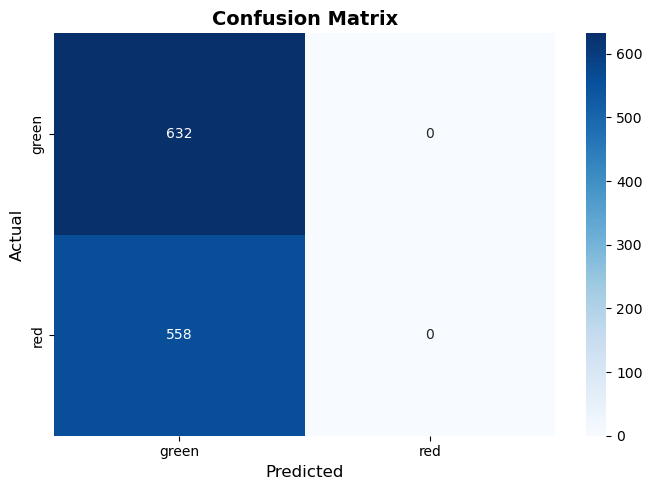


Epoch     1
Train_cost  = 0.7009 | Test_cost  = 0.6929 | Train_score = 0.4949 | Test_score = 0.5311 |


─────────────────────────────────────────────────── 🚀 EPOCH 2 ────────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1240.53it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6951 │ 0.6922 │ │ green │  1.0000  │
│ Accuracy │ 0.4919 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.3764 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

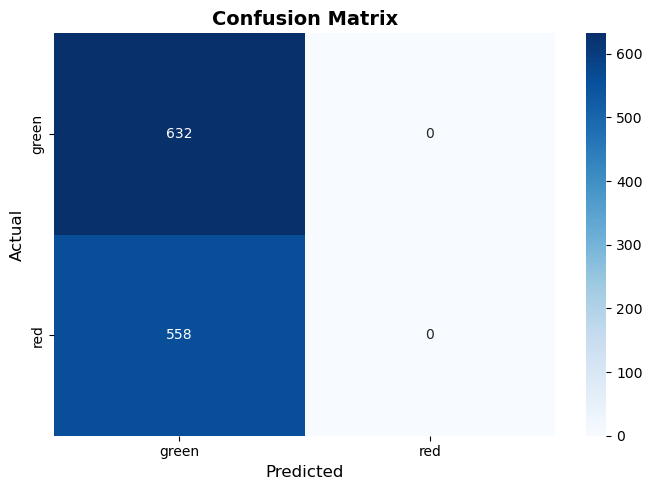


Epoch     2
Train_cost  = 0.6951 | Test_cost  = 0.6922 | Train_score = 0.4919 | Test_score = 0.5311 |
==> EarlyStop patience =  1 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 3 ────────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1250.73it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6939 │ 0.6923 │ │ green │  0.9953  │
│ Accuracy │ 0.4931 │ 0.5286 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4813 │ 0.3458 │ └───────┴──────────┘
└──────────┴────────┴────────┘

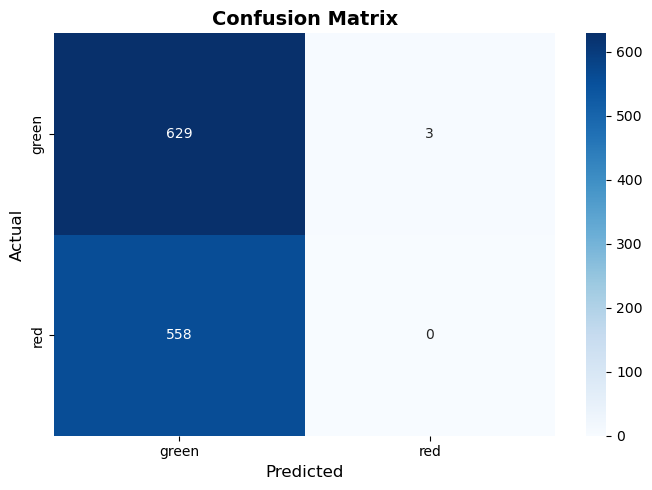


Epoch     3
Train_cost  = 0.6939 | Test_cost  = 0.6923 | Train_score = 0.4931 | Test_score = 0.5286 |
==> EarlyStop patience =  2 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 4 ────────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1256.61it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6935 │ 0.6923 │ │ green │  0.9889  │
│ Accuracy │ 0.4969 │ 0.5277 │ │  red  │  0.0054  │
│ Macro F1 │ 0.4959 │ 0.3502 │ └───────┴──────────┘
└──────────┴────────┴────────┘

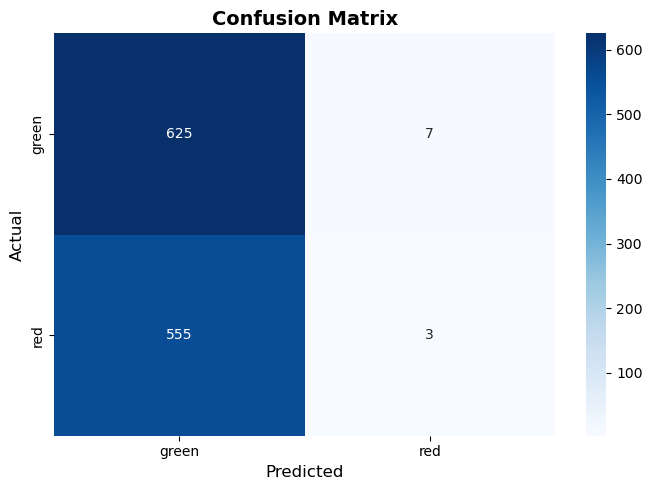


Epoch     4
Train_cost  = 0.6935 | Test_cost  = 0.6923 | Train_score = 0.4969 | Test_score = 0.5277 |
==> EarlyStop patience =  3 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 5 ────────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1278.16it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6934 │ 0.6923 │ │ green │  0.9889  │
│ Accuracy │ 0.5025 │ 0.5277 │ │  red  │  0.0054  │
│ Macro F1 │ 0.4945 │ 0.3502 │ └───────┴──────────┘
└──────────┴────────┴────────┘

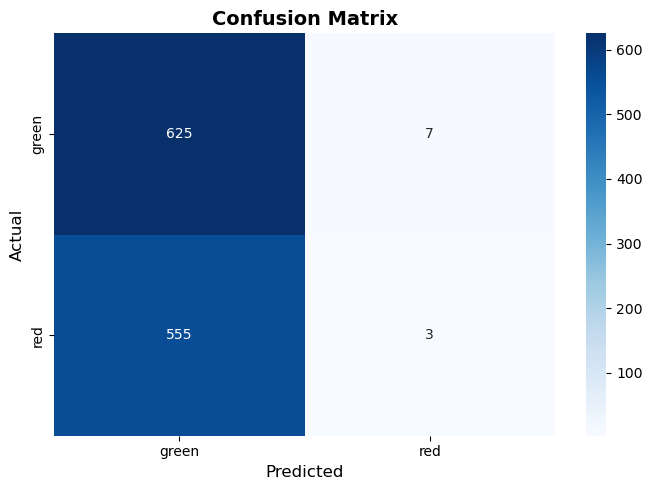


Epoch     5
Train_cost  = 0.6934 | Test_cost  = 0.6923 | Train_score = 0.5025 | Test_score = 0.5277 |
==> EarlyStop patience =  4 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 6 ────────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1202.39it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6933 │ 0.6923 │ │ green │  0.9937  │
│ Accuracy │ 0.5016 │ 0.5286 │ │  red  │  0.0018  │
│ Macro F1 │ 0.4892 │ 0.3474 │ └───────┴──────────┘
└──────────┴────────┴────────┘

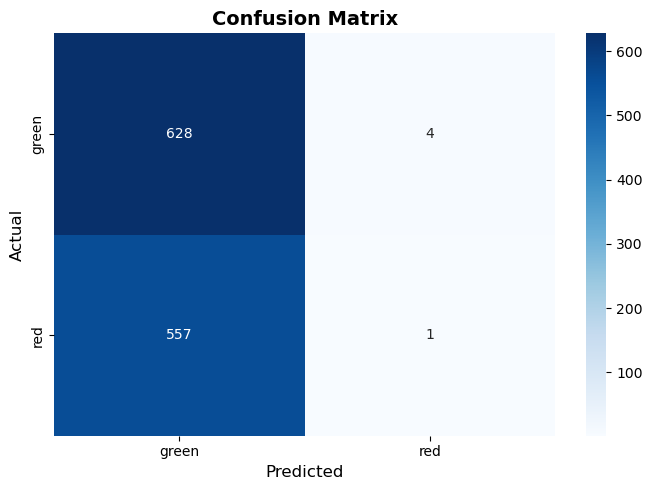


Epoch     6
Train_cost  = 0.6933 | Test_cost  = 0.6923 | Train_score = 0.5016 | Test_score = 0.5286 |
==> EarlyStop patience =  5 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 7 ────────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1286.25it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6923 │ │ green │  0.9953  │
│ Accuracy │ 0.5011 │ 0.5286 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4855 │ 0.3458 │ └───────┴──────────┘
└──────────┴────────┴────────┘

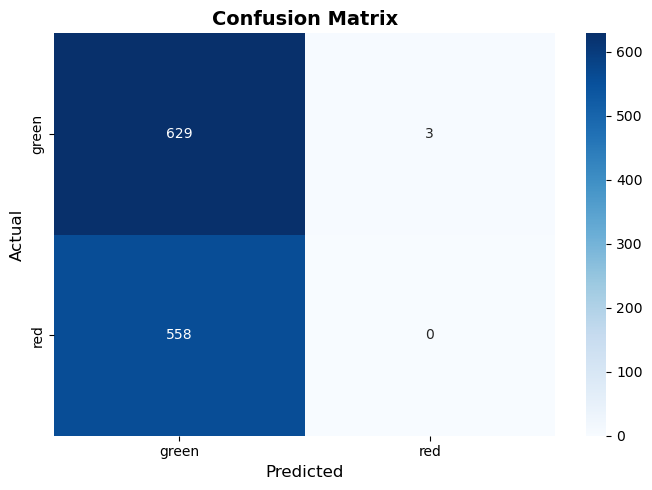


Epoch     7
Train_cost  = 0.6932 | Test_cost  = 0.6923 | Train_score = 0.5011 | Test_score = 0.5286 |
==> EarlyStop patience =  6 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 8 ────────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1223.27it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6932 │ 0.6923 │ │ green │  1.0000  │
│ Accuracy │ 0.5033 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4861 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

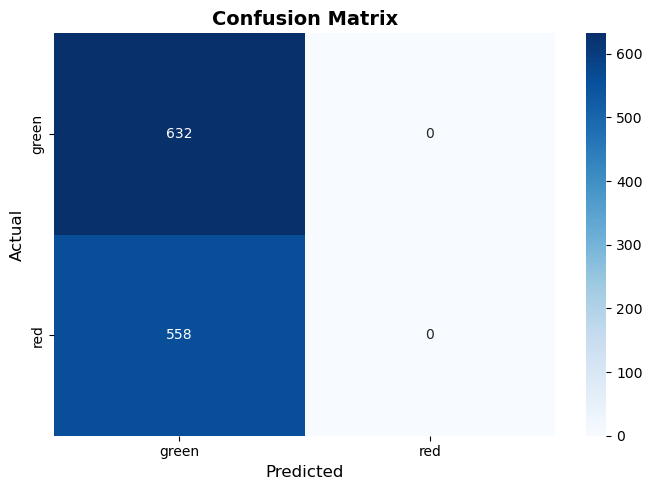


Epoch     8
Train_cost  = 0.6932 | Test_cost  = 0.6923 | Train_score = 0.5033 | Test_score = 0.5311 |
==> EarlyStop patience =  7 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 9 ────────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1292.15it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6931 │ 0.6923 │ │ green │  1.0000  │
│ Accuracy │ 0.5024 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4833 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

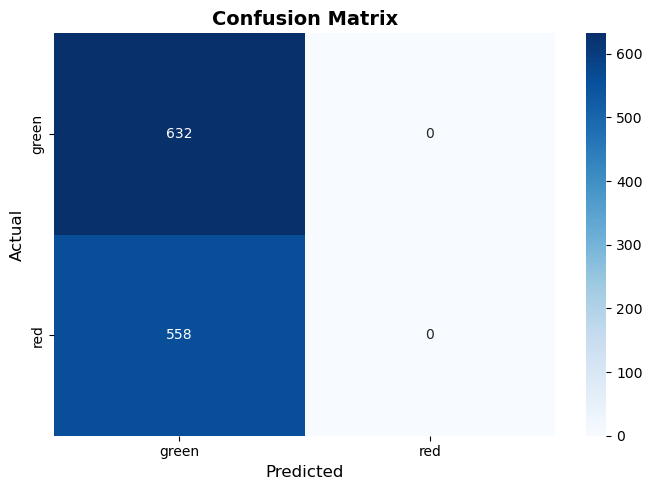


Epoch     9
Train_cost  = 0.6931 | Test_cost  = 0.6923 | Train_score = 0.5024 | Test_score = 0.5311 |
==> EarlyStop patience =  8 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 10 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1052.14it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6930 │ 0.6922 │ │ green │  1.0000  │
│ Accuracy │ 0.5054 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4848 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

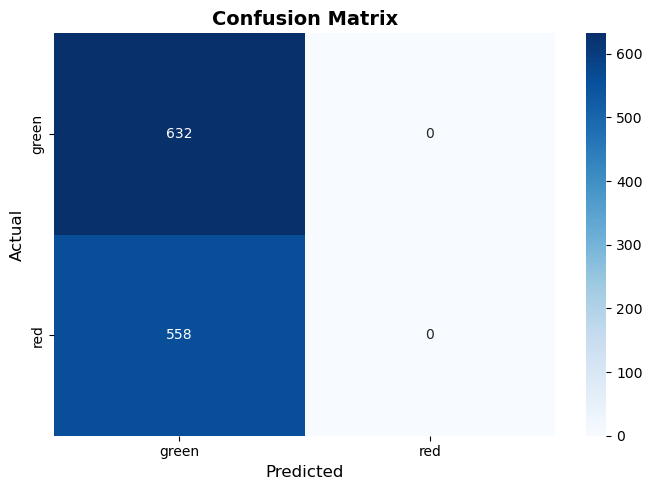


Epoch    10
Train_cost  = 0.6930 | Test_cost  = 0.6922 | Train_score = 0.5054 | Test_score = 0.5311 |
==> EarlyStop patience =  9 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 11 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1219.12it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6930 │ 0.6922 │ │ green │  1.0000  │
│ Accuracy │ 0.5042 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4815 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

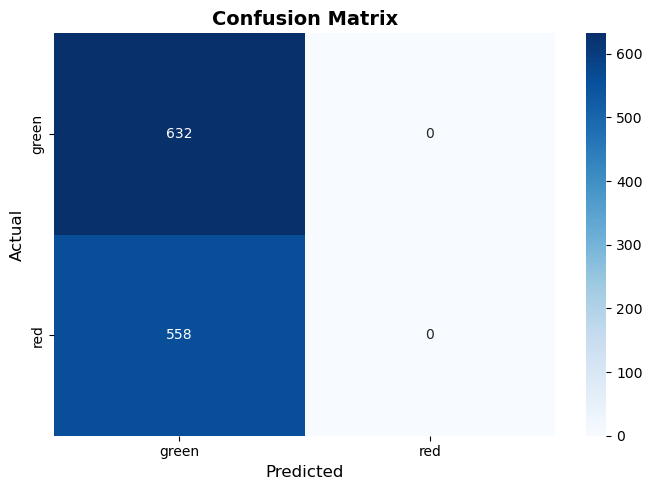


Epoch    11
Train_cost  = 0.6930 | Test_cost  = 0.6922 | Train_score = 0.5042 | Test_score = 0.5311 |
==> EarlyStop patience = 10 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 12 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1217.70it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6929 │ 0.6922 │ │ green │  1.0000  │
│ Accuracy │ 0.5049 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4820 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

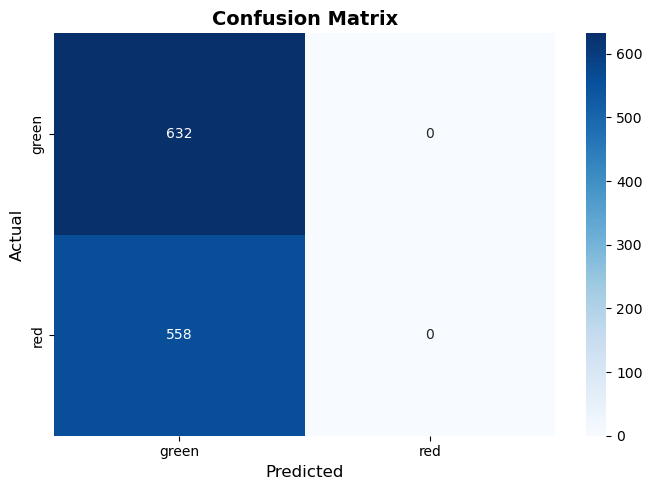


Epoch    12
Train_cost  = 0.6929 | Test_cost  = 0.6922 | Train_score = 0.5049 | Test_score = 0.5311 |
==> EarlyStop patience = 11 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 13 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1125.21it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6929 │ 0.6922 │ │ green │  1.0000  │
│ Accuracy │ 0.5033 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4800 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

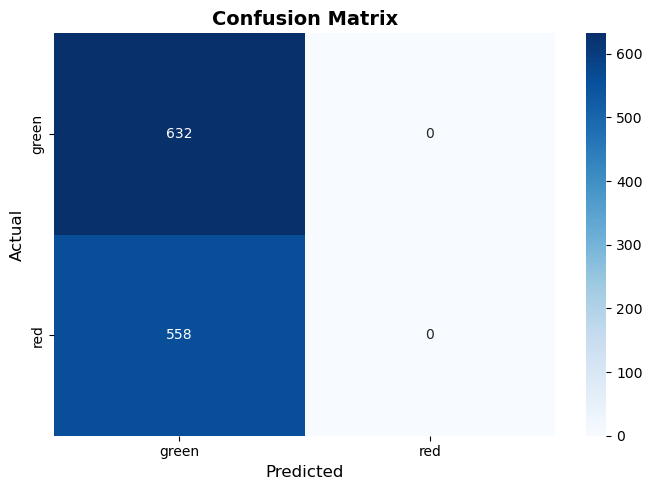


Epoch    13
Train_cost  = 0.6929 | Test_cost  = 0.6922 | Train_score = 0.5033 | Test_score = 0.5311 |
==> EarlyStop patience = 12 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 14 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1092.03it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6929 │ 0.6922 │ │ green │  1.0000  │
│ Accuracy │ 0.5058 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4822 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

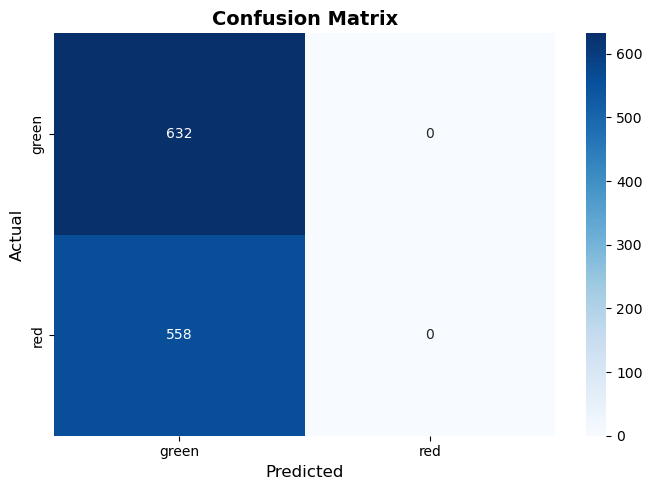


Epoch    14
Train_cost  = 0.6929 | Test_cost  = 0.6922 | Train_score = 0.5058 | Test_score = 0.5311 |
==> EarlyStop patience = 13 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 15 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1109.52it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6928 │ 0.6922 │ │ green │  1.0000  │
│ Accuracy │ 0.5067 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4827 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

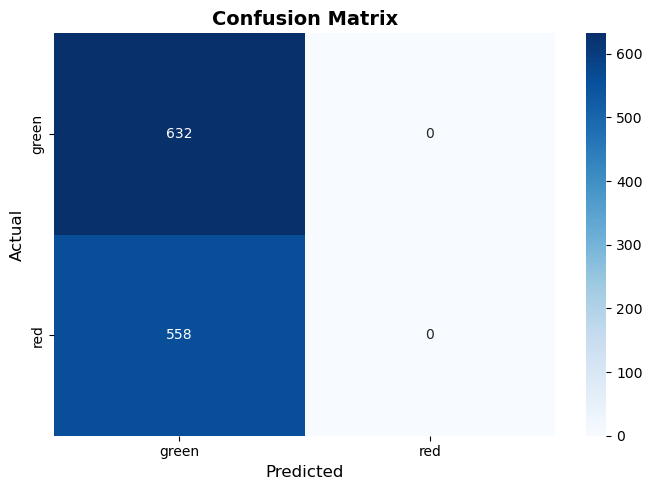


Epoch    15
Train_cost  = 0.6928 | Test_cost  = 0.6922 | Train_score = 0.5067 | Test_score = 0.5311 |
==> EarlyStop patience = 14 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 16 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1328.95it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6928 │ 0.6922 │ │ green │  1.0000  │
│ Accuracy │ 0.5092 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4857 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

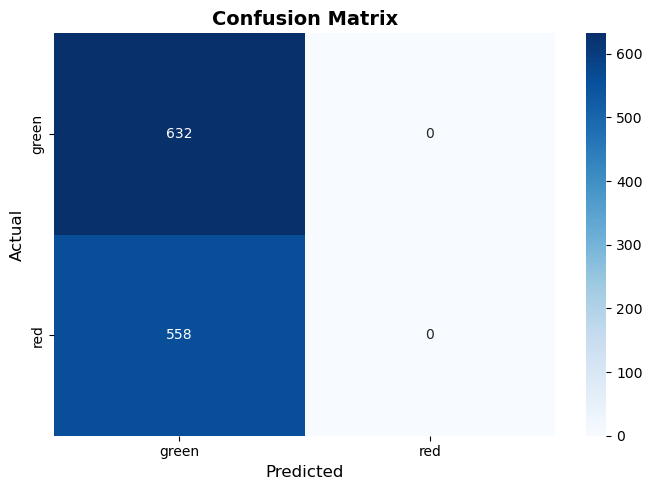


Epoch    16
Train_cost  = 0.6928 | Test_cost  = 0.6922 | Train_score = 0.5092 | Test_score = 0.5311 |
==> EarlyStop patience = 15 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 17 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1265.08it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6927 │ 0.6922 │ │ green │  1.0000  │
│ Accuracy │ 0.5098 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4868 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

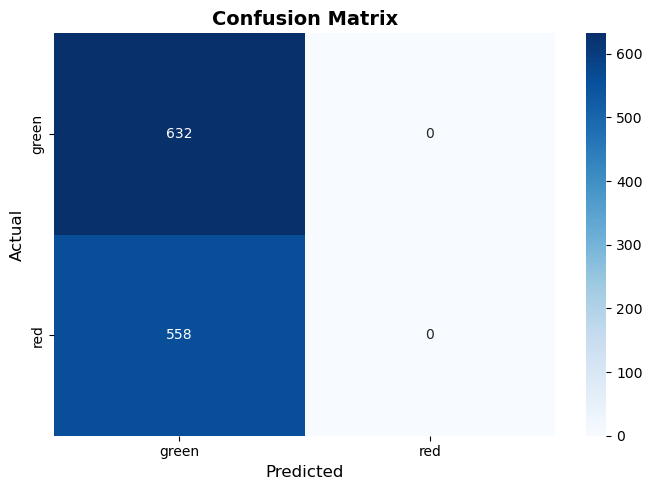


Epoch    17
Train_cost  = 0.6927 | Test_cost  = 0.6922 | Train_score = 0.5098 | Test_score = 0.5311 |
==> EarlyStop patience = 16 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 18 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1207.18it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6927 │ 0.6922 │ │ green │  1.0000  │
│ Accuracy │ 0.5107 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4879 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

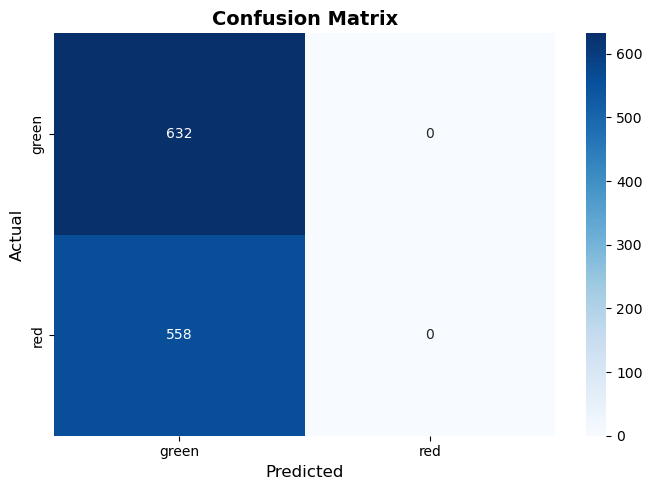


Epoch    18
Train_cost  = 0.6927 | Test_cost  = 0.6922 | Train_score = 0.5107 | Test_score = 0.5311 |
==> EarlyStop patience = 17 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 19 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1225.48it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6927 │ 0.6922 │ │ green │  1.0000  │
│ Accuracy │ 0.5074 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4856 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

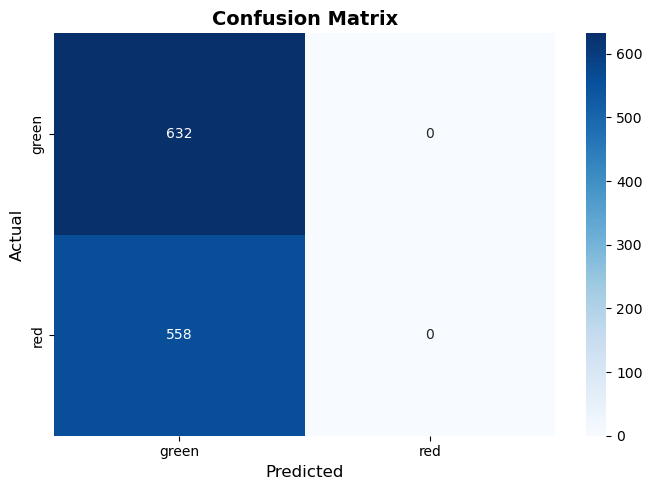


Epoch    19
Train_cost  = 0.6927 | Test_cost  = 0.6922 | Train_score = 0.5074 | Test_score = 0.5311 |
==> EarlyStop patience = 18 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 20 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1305.35it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6926 │ 0.6922 │ │ green │  1.0000  │
│ Accuracy │ 0.5078 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4867 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

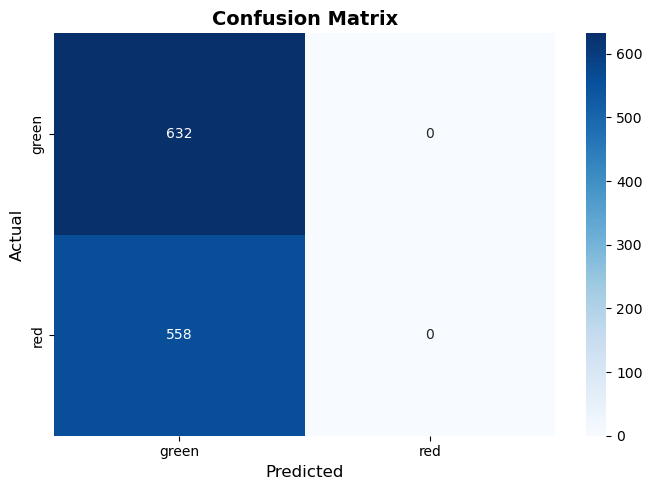


Epoch    20
Train_cost  = 0.6926 | Test_cost  = 0.6922 | Train_score = 0.5078 | Test_score = 0.5311 |


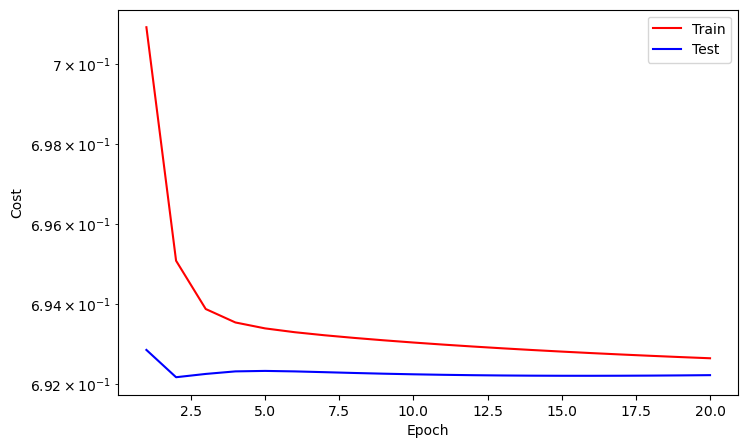

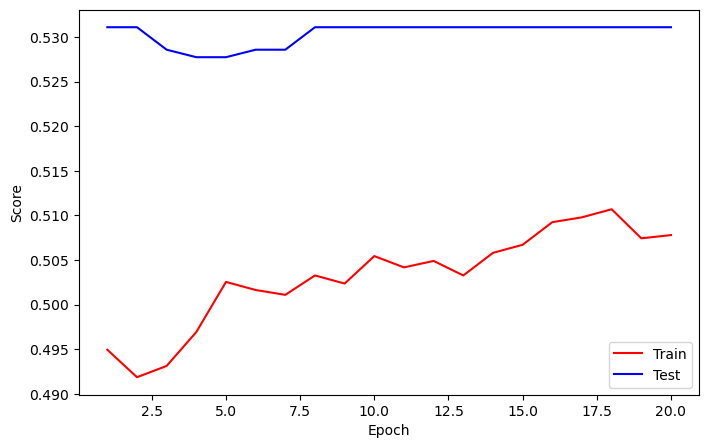

==> EarlyStop patience = 19 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 21 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1340.28it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6926 │ 0.6922 │ │ green │  1.0000  │
│ Accuracy │ 0.5081 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4883 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

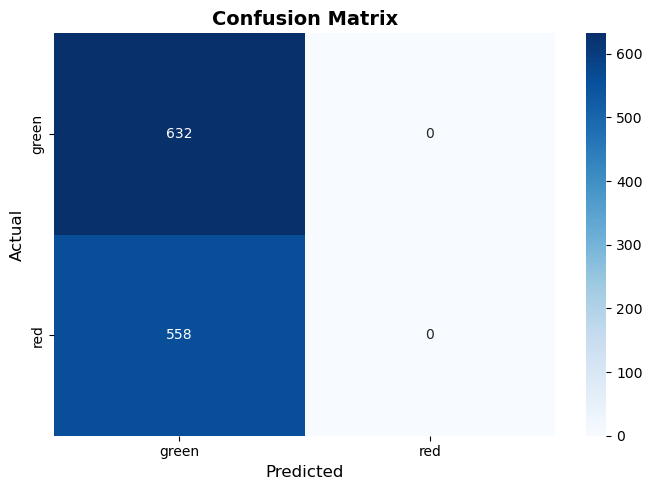


Epoch    21
Train_cost  = 0.6926 | Test_cost  = 0.6922 | Train_score = 0.5081 | Test_score = 0.5311 |
==> EarlyStop patience = 20 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 22 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1356.41it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6926 │ 0.6922 │ │ green │  1.0000  │
│ Accuracy │ 0.5094 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4906 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

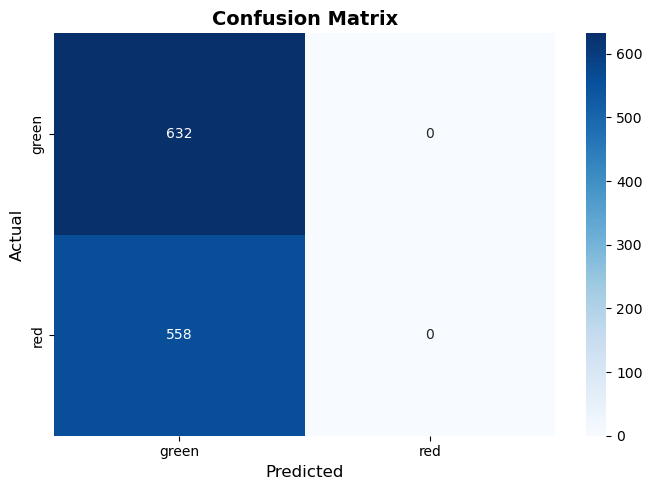


Epoch    22
Train_cost  = 0.6926 | Test_cost  = 0.6922 | Train_score = 0.5094 | Test_score = 0.5311 |
==> EarlyStop patience = 21 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 23 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1328.48it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6926 │ 0.6923 │ │ green │  1.0000  │
│ Accuracy │ 0.5094 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4917 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

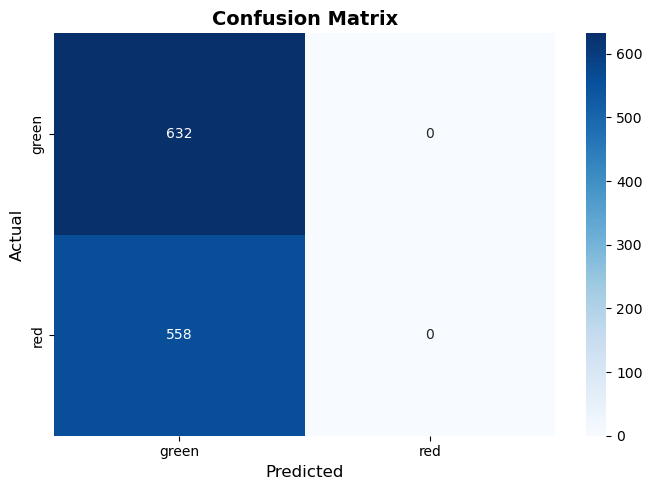


Epoch    23
Train_cost  = 0.6926 | Test_cost  = 0.6923 | Train_score = 0.5094 | Test_score = 0.5311 |
==> EarlyStop patience = 22 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 24 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1334.60it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6925 │ 0.6923 │ │ green │  1.0000  │
│ Accuracy │ 0.5105 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4941 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

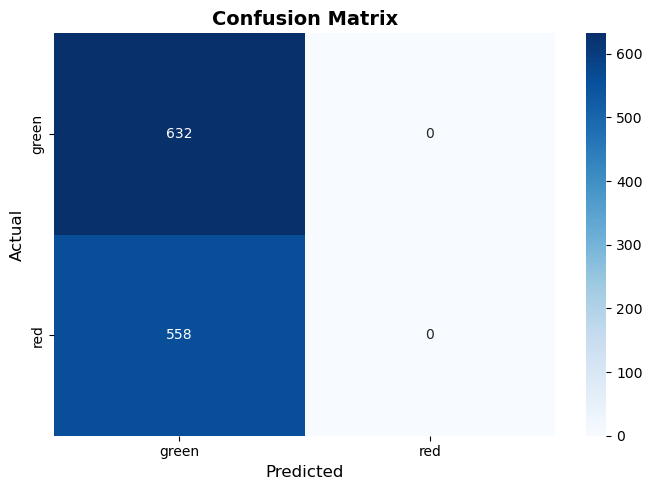


Epoch    24
Train_cost  = 0.6925 | Test_cost  = 0.6923 | Train_score = 0.5105 | Test_score = 0.5311 |
==> EarlyStop patience = 23 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 25 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1318.01it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6925 │ 0.6923 │ │ green │  1.0000  │
│ Accuracy │ 0.5087 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4933 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

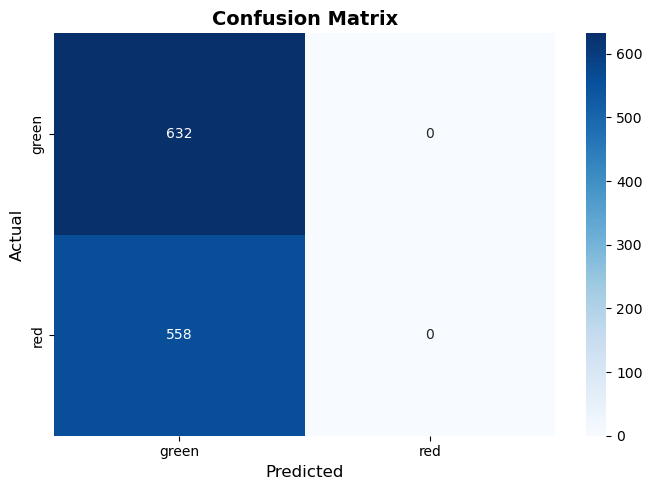


Epoch    25
Train_cost  = 0.6925 | Test_cost  = 0.6923 | Train_score = 0.5087 | Test_score = 0.5311 |
==> EarlyStop patience = 24 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 26 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1352.63it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6925 │ 0.6923 │ │ green │  1.0000  │
│ Accuracy │ 0.5109 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4964 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

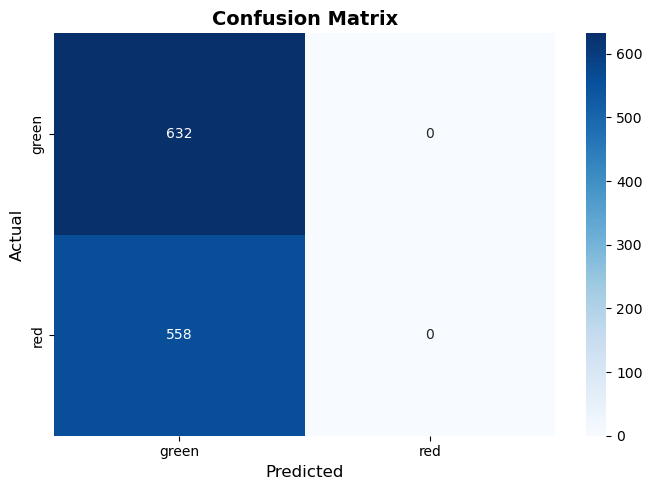


Epoch    26
Train_cost  = 0.6925 | Test_cost  = 0.6923 | Train_score = 0.5109 | Test_score = 0.5311 |
==> EarlyStop patience = 25 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 27 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1346.99it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6925 │ 0.6923 │ │ green │  1.0000  │
│ Accuracy │ 0.5089 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4950 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

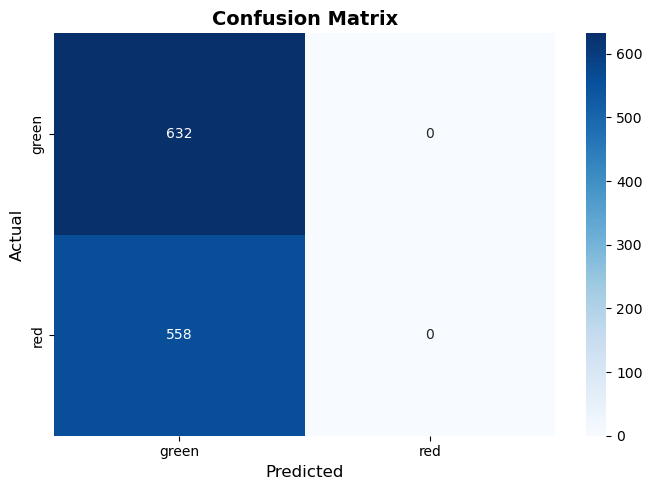


Epoch    27
Train_cost  = 0.6925 | Test_cost  = 0.6923 | Train_score = 0.5089 | Test_score = 0.5311 |
==> EarlyStop patience = 26 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 28 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1369.30it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6925 │ 0.6923 │ │ green │  1.0000  │
│ Accuracy │ 0.5089 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4958 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

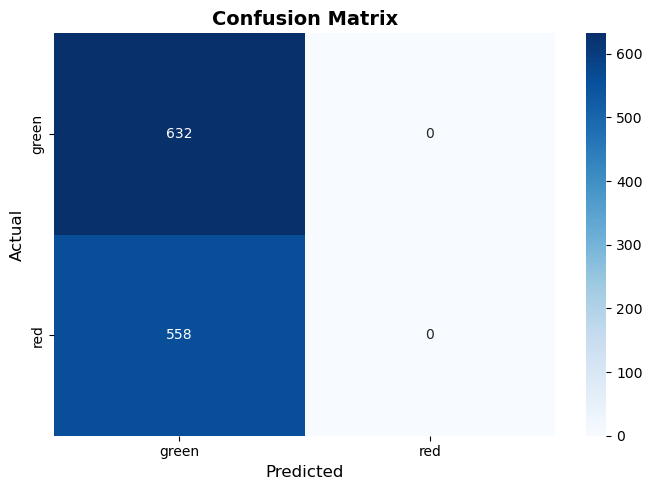


Epoch    28
Train_cost  = 0.6925 | Test_cost  = 0.6923 | Train_score = 0.5089 | Test_score = 0.5311 |
==> EarlyStop patience = 27 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 29 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1153.80it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6924 │ 0.6923 │ │ green │  1.0000  │
│ Accuracy │ 0.5112 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.4992 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

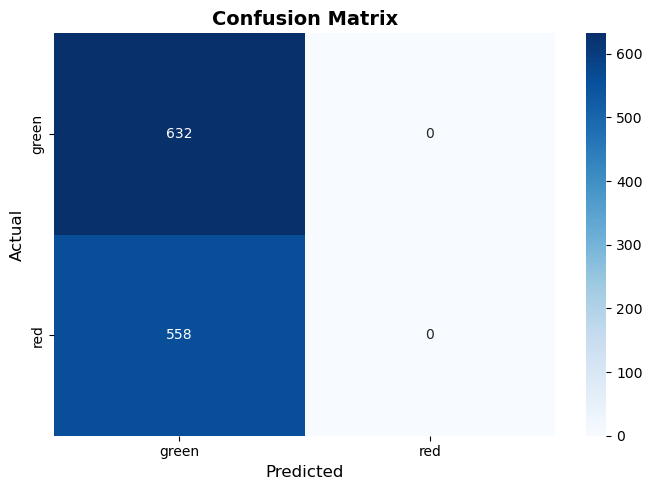


Epoch    29
Train_cost  = 0.6924 | Test_cost  = 0.6923 | Train_score = 0.5112 | Test_score = 0.5311 |
==> EarlyStop patience = 28 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 30 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1241.97it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6924 │ 0.6924 │ │ green │  1.0000  │
│ Accuracy │ 0.5130 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.5018 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

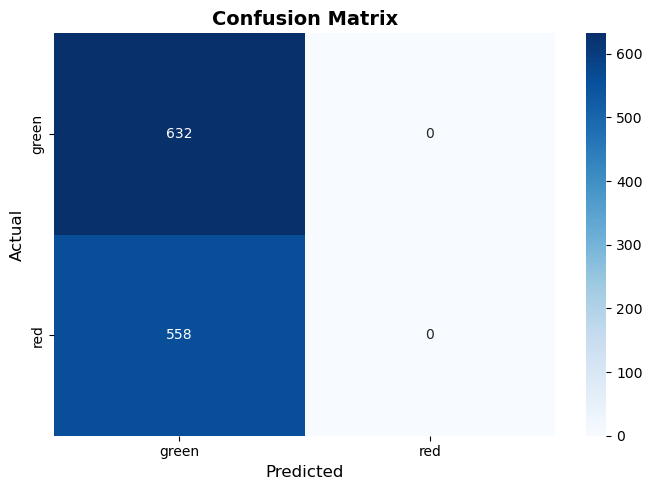


Epoch    30
Train_cost  = 0.6924 | Test_cost  = 0.6924 | Train_score = 0.5130 | Test_score = 0.5311 |
==> EarlyStop patience = 29 | Best test_score: 0.5311


─────────────────────────────────────────────────── 🚀 EPOCH 31 ───────────────────────────────────────────────────

test: 100%|██████████| 38/38 [00:00<00:00, 1317.64it/s]


           Summary              Per-Class Accuracy 
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃ Class ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6924 │ 0.6924 │ │ green │  1.0000  │
│ Accuracy │ 0.5129 │ 0.5311 │ │  red  │  0.0000  │
│ Macro F1 │ 0.5024 │ 0.3469 │ └───────┴──────────┘
└──────────┴────────┴────────┘

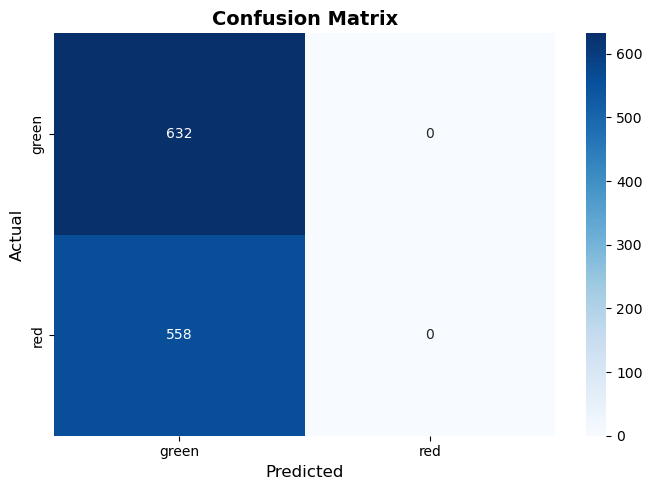


Epoch    31
Train_cost  = 0.6924 | Test_cost  = 0.6924 | Train_score = 0.5129 | Test_score = 0.5311 |
==> EarlyStop patience = 30 | Best test_score: 0.5311
==> Execute Early Stopping at epoch: 31 | Best test_score: 0.5311
==> Best model is saved at timeseris/multi-class-clasification/rnn/microsoft_stock_data/


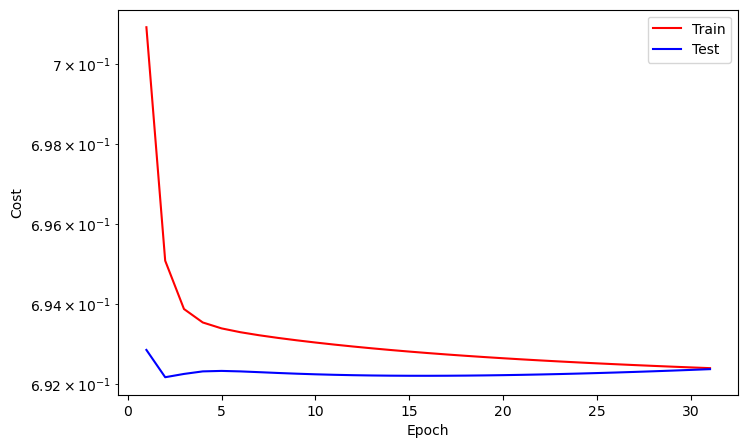

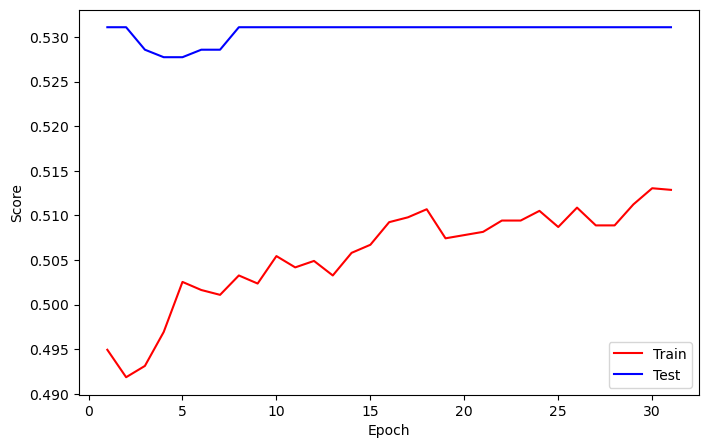

⏹️ Training dihentikan oleh early stopping.

In [76]:
from train_and_evaluate import train_and_evaluate_multi_class

train_and_evaluate_multi_class(
    model=model,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optim=optim,
    config=config,
    device=device,
    labels=labels,          
    callback=callback
)

# Evaluate

      📊 Evaluasi Model            🎯 Per-Class    
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metrik            ┃  Nilai ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┃ Class ┃ Accuracy ┃
│ 💥 Loss (avg)     │ 0.6925 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ 🔹 Accuracy       │ 0.5277 │ │ green │  0.7737  │
│ 📈 Macro F1-score │ 0.4830 │ │  red  │  0.2491  │
└───────────────────┴────────┘ └───────┴──────────┘

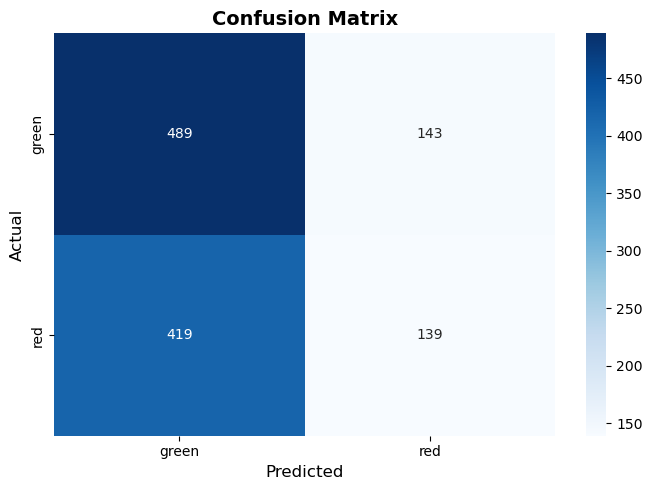

In [51]:
from evaluate import evaluate_multi_class
hsl = evaluate_multi_class(
    model=model,
    dataloader=test_loader,
    labels=labels,
    criterion=criterion,
    device=device,
    dimension='1d'
)

In [52]:
hsl = hsl['df']
b = hsl[hsl['Benar (%)'] == 100]
b.head(300)

,Target,Prediksi,Prob (%),Benar (%),Benar


In [53]:
b.shape

(0, 5)

In [54]:
s = hsl[hsl['Benar (%)'] == 0]
s.head(300)

,Target,Prediksi,Prob (%),Benar (%),Benar


In [55]:
s.shape

(0, 5)